In [1]:
import numpy as np
import jax.numpy as jnp
from jax.scipy.special import erfc, erf
import matplotlib.pyplot as plt
from log_normal_h2 import get_lnorms, get_h2_mean_var
from pdf_compound_jax import build_population, sample_compound, AstroPopulation
from scipy.special import logsumexp

We can approximate the statistics of the characteristic strain $h^2_c$ using the saddlepoint approximation method. To do so, we need to define a model that gives the comoving number density of GW sources. We use the simple phenomelogical model from (cite)

# $\frac{d^2 n}{dz d\log \mathcal{M}} = \dot{n}_0 \frac{dt}{dz} \times \left ( \frac{\mathcal{M}}{10^7 M_\odot}\right )^{-\alpha} e^{-\mathcal{M} / \mathcal{M}_0} \times (1+z)^{\beta} e^{-z/z_0}$
This is the default model that is used by the code.

We initiate a set of values for the parameters of the model.

In [ ]:
# constants, solar mass and year
m_sun = 2e30
yr = 365.25 * 24 * 3600

# model
alpha = 0.5
log10_m0 = 9.3
m0 = 10**log10_m0 * m_sun
beta = 0.5
z0 = 1.
n0_dot = 1.26e-3

# # model low mass
# alpha = 0.5
# log10_m0 = 8.3
# m0 = 10**log10_m0 * m_sun
# beta = 0.5
# z0 = 1.
# n0_dot = 1.8e-2

# set Tspan and frequencies
Tspan = 20 * yr
freqs = np.arange(1, 20) / Tspan

For this model we can also estimate the mean and variance of the expected characteristic strain $h^2_c$, which can be used for moment matching with some probability distributions (cite).

We also need to define a grid of $h^2_c$ values to plot the distribution.

In [14]:
# get mean and variance of h2c
h2c, var_h2c = get_h2_mean_var(freqs, n0_dot, alpha, m0, beta, z0)

# grid of h2c values
h2 = np.logspace(-36, -26, 5001)
dh2 = np.diff(h2)
h2 = h2[:-1]

# get moment matched log-normal distribution
lnorms = get_lnorms(h2, freqs, n0_dot, alpha, m0, beta, z0)

We create an instance of the class `AstroPopulation` that takes as input the array of frequencies at which the probability distribution will be estimated `freqs` and the list of model parameter names `param_names`.

In [25]:
# set parameter dictionary
params = {'n0_dot':1.26e-3, 'alpha':0.5, 'log10_m0':9.3, 'beta':0.5, 'z0':1.}
param_names = [*params]

# get saddlepoint
astro = AstroPopulation(freqs, param_names)
lnpdfs = astro.get_lnpdf(h2, params)

The `astro.get_lnpdf` function will output an array of size `freqs x h2` that contains the set of probability distributions estimated on the grid `h2` at frequencies `freqs` for the set of model parameters `params`.

We write the following function for custom violin plots.

In [30]:
def plot_violin(x, pdf_x, position, width=1., color='C0', pmin=0.01, label=None):

    mask = pdf_x > pmin * np.amax(pdf_x)
    p = 0.5 * width * pdf_x / np.amax(pdf_x)
    plt.fill_betweenx(x[mask], position + p[mask], position - p[mask], alpha=0.2, color=color, label=label)

We plot the probability distributions with the expected ensemble average for this set of model parameters. Note that the average lies on the higher end of the probability distributions, because the average is dominated by the high $h^2_c$ tail of the distribution.

The model parameters are chosen so that $h_c = 3\times 10^{-15} \left ( f \times yr \right)^{-2/3}$.

To plot $p(h_c)$ we need to perform a small change of variable from the estimated $p(h^2_c)$ as $p(h_c) = 2 |h_c| p(h_c^2)$.

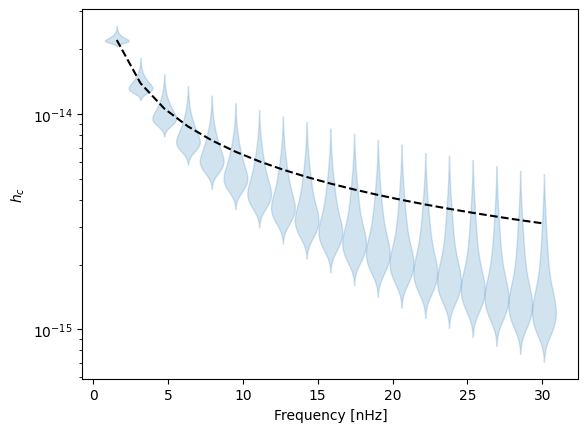

In [28]:
for n, pdf in enumerate(np.exp(lnpdfs)):
    plot_violin(h2**0.5, pdf * 2 * h2**0.5, freqs[n] * 1e9, width=freqs[0] * 1e9)

plt.plot(freqs * 1e9, 3e-15 * (freqs * yr)**(-2/3), ls='--', c='k')
plt.yscale('log')
plt.ylabel('$h_c$')
plt.xlabel('Frequency [nHz]')
# plt.legend(loc='upper right')
plt.show()

The code is written to take as input any function $\frac{d^2 n}{dz d\log \mathcal{M}}$ with alternative parametrisations. Here, we use the mass function defined in [ref](https://arxiv.org/pdf/1906.05138).

Any mass function can be used, ideally, outputs of more elaborate semi-analytical models.

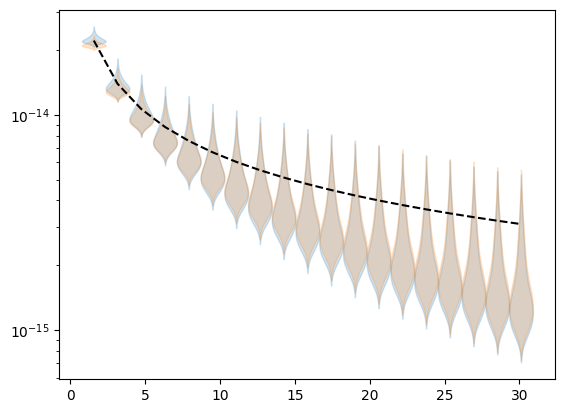

In [29]:
# defined model, the first three arguments must always be z, dt_dz, mc. The others are model parameters.
def d2n_dzdlog10M_new(z, dt_dz, mc, n0_dot, alpha, log10_m0, sig0, beta, z0, gamma):

    # m0 = m_sun * 10**log10_m0
    mc /= m_sun
    m0 = 10**log10_m0

    # astrophysics terms
    mass_term = 0.5 * (alpha * jnp.exp(alpha * m0 + 0.5 * alpha**2 * sig0**2) / (1 - jnp.exp(-alpha * beta))) * mc**(-alpha)
    mass_term *= (erf(2**(-0.5) * (alpha * sig0 - (np.log(mc) - m0 - beta) / sig0)) - erf(2**(-0.5) * (alpha * sig0 - (np.log(mc) - m0) / sig0)))
    redshift_term = z**gamma * jnp.exp(-z/z0) * dt_dz

    return n0_dot * mass_term * redshift_term

# define a set of parameters
params_new = {'n0_dot':5e-2, 'alpha':0.5, 'log10_m0':1.04, 'sig0':0.75, 'beta':10, 'z0':1., 'gamma':0.5}

# create astro population instance with the new model given through the argument d2n_dzdlog10M
astro_new = AstroPopulation(freqs, [*params_new], d2n_dzdlog10M=d2n_dzdlog10M_new)
lnpdfs_new = astro_new.get_lnpdf(h2, params_new)

# overplot old and new models
plt.plot(freqs * 1e9, 3e-15 * (freqs * yr)**(-2/3), ls='--', c='k')
for n, pdf in enumerate(np.exp(lnpdfs)):
    plot_violin(h2**0.5, pdf * 2 * h2**0.5, freqs[n] * 1e9, width=freqs[0] * 1e9, color='C0')

for n, pdf in enumerate(np.exp(lnpdfs_new)):
    plot_violin(h2**0.5, pdf * 2 * h2**0.5, freqs[n] * 1e9, width=freqs[0] * 1e9, color='C1')
plt.yscale('log')
plt.show()
